In [ ]:
 #instalaciones
import pandas as pd
import numpy as np
!pip install openpyxl
!pip install dython
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel('ensanut_raw_oficial_21_23.xlsx')


In [ ]:
#los valores faltantes los tenia como ?, lso cambie por NaN
df = df.replace('?', np.nan)


cesd7 tiene una distribución sesgada a la derecha (cola larga), tambien presenta un valor elevado, lo cual indica la mayor presencia de valores extremos.


ANALISIS BIVARIANTE CON: riesgo/sin riesgo depresion

In [ ]:
#se pasa la variable numerica edad a categorica para matriz de correlacion:
"""
a manera de criterio, en primer lugar se diferenciaron los grupos de edad entre <60 y +60
por la diferencia en los puntos de corte del CESD7
, posteriormente se separaron en jove, adulto de mediana edad, adulto y adulto mayor
"""
#rangos
df['edad_bin'] = pd.cut(
    df['edad'],
    bins=[20, 35, 50, 60, 101],
    labels=['20-34', '35-49', '50-59', '60+'],
    right=False # intervalos cerrados por la izquierda, abiertos por la derecha, excluye valor limite
)
df['edad_bin'].value_counts(normalize=True).sort_index()

edad_bin
20-34    0.296026
35-49    0.302696
50-59    0.173664
60+      0.227614
Name: proportion, dtype: float64

Excel guardado en: /content/drive/MyDrive/Maestria_DATA/ensanut/procesamiento_2026a/eda/prueba_chi_pvalores.xlsx


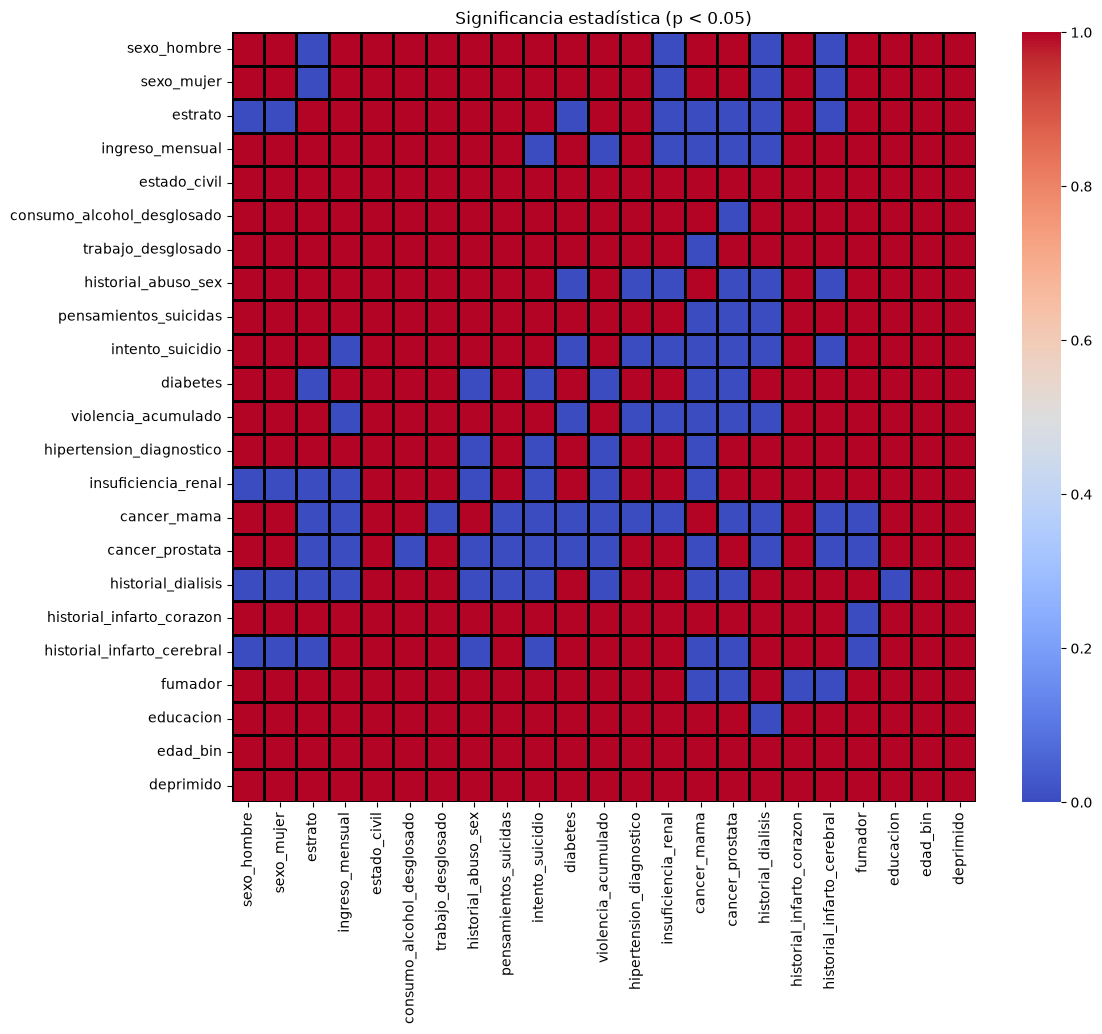

In [ ]:
#analisis multivariante con variable objetivo BINARIA:
variables_cat = ['sexo_hombre', 'sexo_mujer', 'estrato', 'ingreso_mensual', 'estado_civil', 'consumo_alcohol_desglosado', 'trabajo_desglosado', 'historial_abuso_sex',
                 'pensamientos_suicidas', 'intento_suicidio', 'diabetes', 'violencia_acumulado', 'hipertension_diagnostico', 'insuficiencia_renal', 'cancer_mama',
                 'cancer_prostata', 'historial_dialisis', 'historial_infarto_corazon', 'historial_infarto_cerebral', 'fumador', 'educacion', 'edad_bin','deprimido']

#hacer modificaciones para  que no aparezca suicidio y sexo hombre, que haga match, 20 variables
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

def matriz_chi2_pvalues(df, variables):
    n = len(variables)
    p_matrix = pd.DataFrame(np.ones((n, n)), index=variables, columns=variables)

    for i, var1 in enumerate(variables):
        for j, var2 in enumerate(variables):

            tabla = pd.crosstab(df[var1], df[var2])

            chi2, p_val, dof, expected = chi2_contingency(tabla)

            p_matrix.loc[var1, var2] = p_val
            p_matrix.loc[var2, var1] = p_val  # simetría

    return p_matrix
p_matrix = matriz_chi2_pvalues(df, variables_cat)
p_matrix

 #--- Guardar Excel ---
xlsx_path = os.path.join(save_path, 'prueba_chi_pvalores.xlsx')
with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
    for sheet_name, tabla in p_matrix.items():
        tabla.to_excel(writer, sheet_name=sheet_name)
print(f"Excel guardado en: {xlsx_path}")


plt.figure(figsize=(12,10))

sns.heatmap(
    p_matrix < 0.05,   # ver si la asociacion entre variables es estadísticamente significativa
    linewidths=0.8,
    linecolor="black",
    cmap='coolwarm',

)

plt.title('Significancia estadística (p < 0.05)')
plt.show()

In [ ]:
p_matrix

,sexo_hombre,sexo_mujer,estrato,ingreso_mensual,estado_civil,consumo_alcohol_desglosado,trabajo_desglosado,historial_abuso_sex,pensamientos_suicidas,intento_suicidio,...,insuficiencia_renal,cancer_mama,cancer_prostata,historial_dialisis,historial_infarto_corazon,historial_infarto_cerebral,fumador,educacion,edad_bin,deprimido
sexo_hombre,0.000000e+00,0.000000e+00,2.762808e-01,6.784532e-15,4.766870e-161,0.000000e+00,0.000000e+00,3.204017e-111,1.846599e-19,2.747778e-13,...,9.711057e-01,2.384168e-13,1.304199e-30,7.916423e-02,6.795996e-03,1.000000e+00,0.000000e+00,5.293005e-46,1.355860e-03,4.339797e-130
sexo_mujer,0.000000e+00,0.000000e+00,2.762808e-01,6.784532e-15,4.766870e-161,0.000000e+00,0.000000e+00,3.204017e-111,1.846599e-19,2.747778e-13,...,9.711057e-01,2.384168e-13,1.304199e-30,7.916423e-02,6.795996e-03,1.000000e+00,0.000000e+00,5.293005e-46,1.355860e-03,4.339797e-130
estrato,2.762808e-01,2.762808e-01,0.000000e+00,0.000000e+00,1.101854e-69,7.359597e-52,1.454445e-118,4.815994e-49,6.768656e-17,3.069553e-09,...,8.483182e-01,1.850237e-01,3.843810e-01,7.471573e-02,6.085941e-04,6.315892e-01,1.631040e-56,0.000000e+00,2.336585e-06,1.077543e-02
ingreso_mensual,6.784532e-15,6.784532e-15,0.000000e+00,0.000000e+00,4.363999e-96,4.862692e-151,6.289659e-252,3.219580e-12,2.616125e-04,3.228763e-01,...,8.817679e-01,6.748041e-01,8.398246e-01,8.698902e-01,7.396602e-03,5.880022e-04,4.235881e-18,0.000000e+00,7.442349e-116,1.385638e-100
estado_civil,4.766870e-161,4.766870e-161,1.101854e-69,4.363999e-96,0.000000e+00,7.894747e-245,0.000000e+00,1.181149e-28,1.635729e-44,3.034819e-25,...,4.121882e-11,4.378916e-03,1.337469e-05,1.670818e-02,1.010002e-17,1.656240e-13,4.018495e-118,0.000000e+00,0.000000e+00,0.000000e+00
consumo_alcohol_desglosado,0.000000e+00,0.000000e+00,7.359597e-52,4.862692e-151,7.894747e-245,0.000000e+00,0.000000e+00,1.575725e-20,1.878520e-12,9.839018e-06,...,1.522329e-05,2.158518e-02,1.600687e-01,3.816610e-04,4.329476e-05,6.496879e-07,0.000000e+00,0.000000e+00,0.000000e+00,4.529381e-70
trabajo_desglosado,0.000000e+00,0.000000e+00,1.454445e-118,6.289659e-252,0.000000e+00,0.000000e+00,0.000000e+00,8.347942e-07,1.499356e-12,7.878411e-08,...,4.366995e-39,3.794581e-01,4.682560e-37,7.632162e-18,4.107837e-43,3.337444e-59,6.869098e-228,0.000000e+00,0.000000e+00,8.157423e-194
historial_abuso_sex,3.204017e-111,3.204017e-111,4.815994e-49,3.219580e-12,1.181149e-28,1.575725e-20,8.347942e-07,0.000000e+00,0.000000e+00,2.306984e-265,...,2.388442e-01,2.454361e-08,1.973469e-01,7.032216e-01,7.860402e-06,8.535141e-02,2.429013e-05,2.669071e-34,1.953614e-26,4.655020e-55
pensamientos_suicidas,1.846599e-19,1.846599e-19,6.768656e-17,2.616125e-04,1.635729e-44,1.878520e-12,1.499356e-12,0.000000e+00,0.000000e+00,0.000000e+00,...,1.308696e-02,6.458591e-02,2.190451e-01,1.216590e-01,2.257693e-10,8.666040e-08,2.418290e-30,2.608315e-03,3.349074e-20,3.252451e-266
intento_suicidio,2.747778e-13,2.747778e-13,3.069553e-09,3.228763e-01,3.034819e-25,9.839018e-06,7.878411e-08,2.306984e-265,0.000000e+00,0.000000e+00,...,1.213638e-01,8.809106e-02,7.835712e-01,1.462782e-01,3.349426e-10,1.946907e-01,1.073628e-25,3.244912e-05,2.758327e-27,1.983665e-86


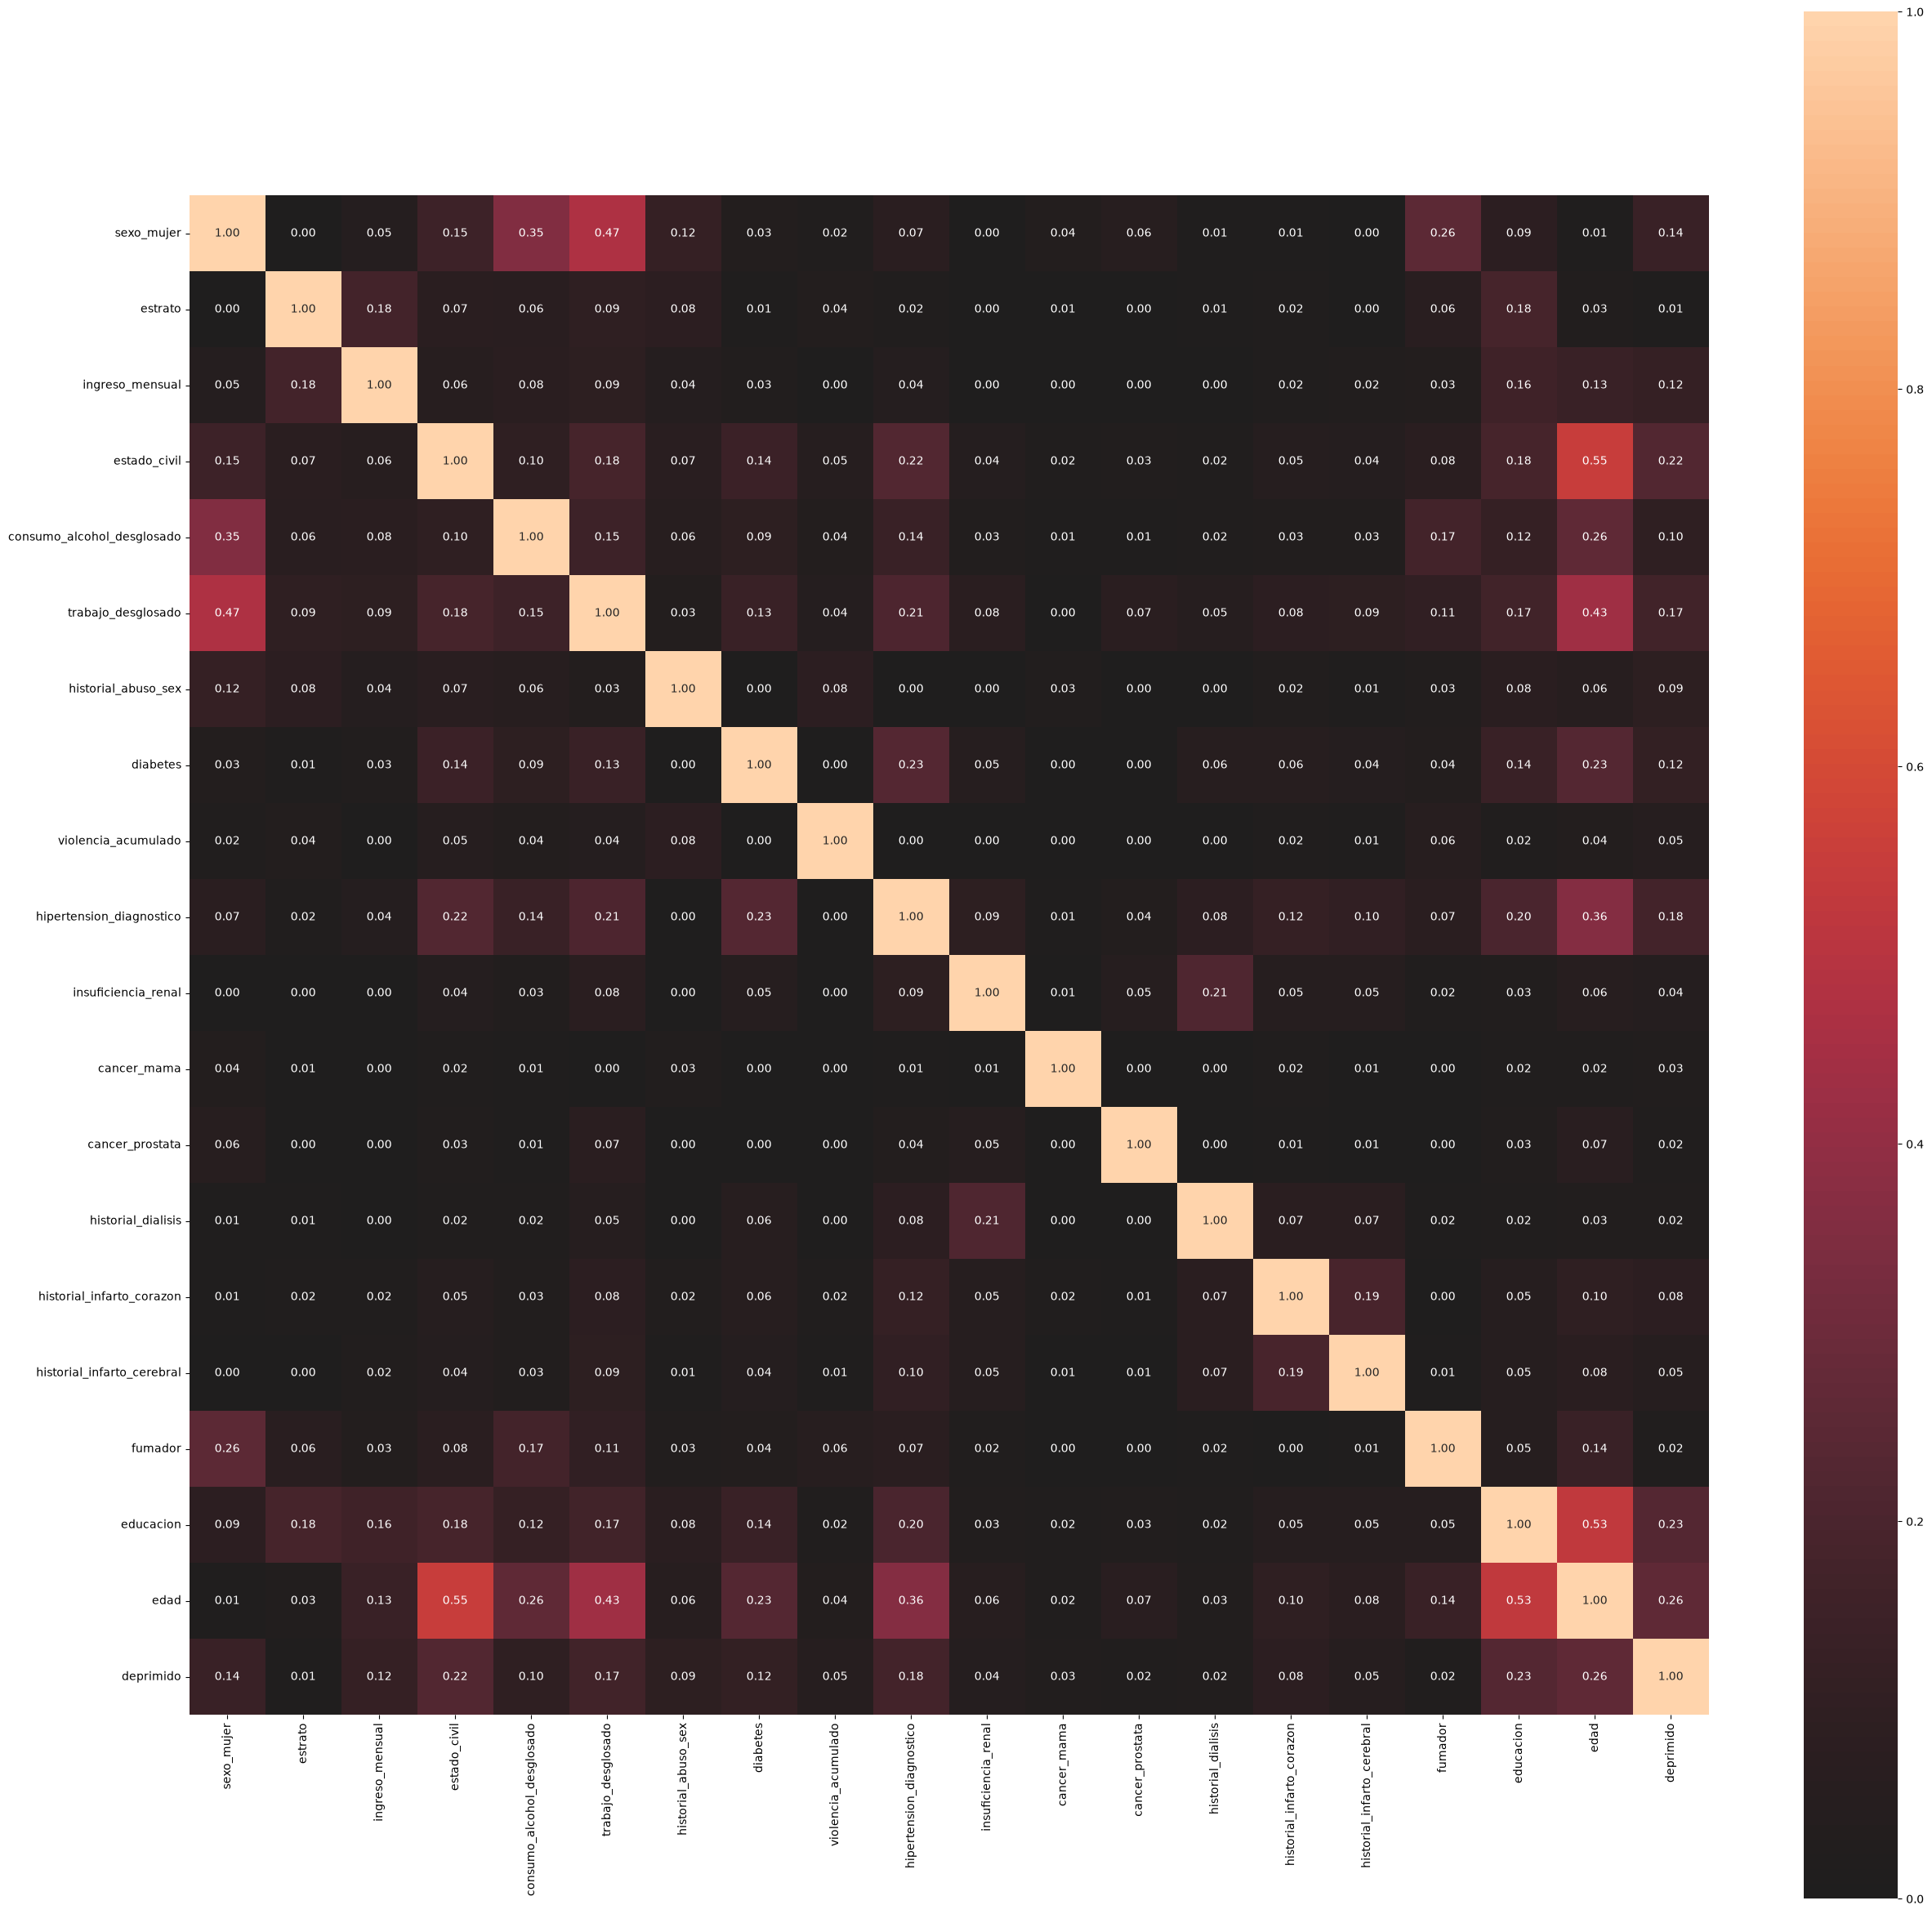

<Figure size 640x480 with 0 Axes>

Imagen guardada: /content/drive/MyDrive/Maestria_DATA/ensanut/procesamiento_2026a/eda/matriz_asociaciones.png


In [ ]:
#matriz de asociaciones con v de cramer, usand dython
import os
import matplotlib.pyplot as plt
from dython.nominal import associations

save_path = "/content/drive/MyDrive/Maestria_DATA/ensanut/procesamiento_2026a/eda"

dataset_edad_num = df[
    ['sexo_mujer', 'estrato', 'ingreso_mensual',
     'estado_civil', 'consumo_alcohol_desglosado', 'trabajo_desglosado',
     'historial_abuso_sex',
     'diabetes', 'violencia_acumulado', 'hipertension_diagnostico',
     'insuficiencia_renal', 'cancer_mama', 'cancer_prostata',
     'historial_dialisis', 'historial_infarto_corazon',
     'historial_infarto_cerebral', 'fumador', 'educacion',
     'edad', 'deprimido']
]

# Generar matriz de asociaciones
results = associations(
    dataset_edad_num,
    nominal_columns=[
        'sexo_mujer', 'estrato', 'ingreso_mensual',
        'estado_civil', 'consumo_alcohol_desglosado',
        'trabajo_desglosado', 'historial_abuso_sex',
        'diabetes', 'violencia_acumulado',
        'hipertension_diagnostico', 'insuficiencia_renal',
        'cancer_mama', 'cancer_prostata',
        'historial_dialisis', 'historial_infarto_corazon',
        'historial_infarto_cerebral', 'fumador',
        'educacion', 'deprimido'
    ],
    numerical_columns='edad'
)

# Obtener la figura actual
fig = plt.gcf()

# Guardar imagen
img_path = os.path.join(save_path, "matriz_asociaciones_junio.png")
fig.savefig(img_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"Imagen guardada: {img_path}")

associations usa v de cramer para comparar variable categorica vs categorica, mientras que usa 'correlation_ratio (eta)' para comparar numerica vs categorica, se especifico que la edad es la unica numerica.

correlation ratio: que tanto una variable categorica explica la variabildiad de una variable numerica, tambien va de 0 a 1.

Ambas medidas indican intensidad de asociacion, pero no la dirección.

dython: https://shakedzy.xyz/dython/modules/nominal/

#insights:
A) Análisis univariante:
1. distribución no uniforme entre categorías en: estrato, ingresos,
** la encuesta fue respondida por un 60% de mujeres, sin embargo, de acuerdo a datos oficiales en el país hay aprox un 52% **
2. distribuciones con alguna categoría dominante: casado, no consumir alcohol, trabajar, no fumar
3. para categorías binarias de salud (con/sin) existe un gran desbalance, siendo la mayoría población "sana", lo cual es lo esperado: intento/pensamiento suicidio, eventos de violencia, enfermedades pe diabetes, hipertensión.
4. Educación: actualmente esta demasiado específico, hay que agrupar por nivel, tipo: basica, secundaria, etc.

B) Análisis multivariante - asociaciones
1. Con la prueba de chi cuadrado se encontraron asociaciones estadísticamente significativas con todas las variables, sin embargo, viendo los valores de la v de cramer, se trata de asociaciones pequeñas - moderadas, las mas altas son:
- estado civil, educación, edad
2. otras asociaciones relevantes encontradas fueron entre:
- la edad y: el estado civil, trabajo y educacion (0.43- 0.55)
- el sexo con el trabajo y el consumo de alcohol